# Random Forest Regressor - Model Development Workflow

> **MLCourse · Machine Learning · supervised · regression**

### What you'll learn

1. Fitting a baseline random forest with a **free OOB validation score**.
2. Drawing the **OOB curve** over `n_estimators` and reading diminishing returns.
3. Honest **permutation importance** (unlike biased impurity importances).
4. The actual-vs-predicted scatter that certifies the model.

### Setup cell: libraries, reproducibility, plot styling (run me first).


In [ ]:
try:  # inline plots inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script mode → nothing to configure
    pass

import numpy as np                  # vector maths
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split                  # hold-out split
from sklearn.ensemble import RandomForestRegressor                    # this chapter's model
from sklearn.inspection import permutation_importance                 # honest importance measure
from sklearn.metrics import mean_squared_error, r2_score              # metrics

np.random.seed(42)                  # reproducibility
sns.set_theme()                     # clean styling
plt.rcParams["figure.dpi"] = 100    # light crisp figures


### 1. Data: same fixed 5,000-row California sample as the tree chapter

Identical sampling recipe keeps results comparable with the single decision
tree notebooks - the forest should win on test R² AND report far smaller
train/test gaps.

In [2]:
from pathlib import Path  # portable paths

def find_data_dir():
    # Climb from the running folder to the course's '02_machine_learning' directory,
    # then into its shared 'data' sub-folder.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # one level up per iteration
    return here / "data"

DATA_DIR = find_data_dir()          # canonical data folder

def load_california():
    # Cache-once helper: derive CSV from sklearn's bundled loader only if missing.
    csv_path = DATA_DIR / "california_housing.csv"
    if not csv_path.exists():       # first encounter builds the cache for all notebooks
        from sklearn.datasets import fetch_california_housing   # ships inside scikit-learn
        frame = fetch_california_housing(as_frame=True).frame    # features + target in one frame
        frame.to_csv(csv_path, index=False)                  # persist locally
        print(f"Created cache -> {csv_path}")
    return pd.read_csv(csv_path)

housing = load_california().sample(n=5000, random_state=42).reset_index(drop=True)
target = "MedHouseVal"              # median house value in $100k units (capped at 5.0)
features = [c for c in housing.columns if c != target]

X_train, X_test, y_train, y_test = train_test_split(
    housing[features], housing[target],
    test_size=0.2, random_state=42,                      # identical split as the tree chapter
)
print(f"train {X_train.shape} | test {X_test.shape}")

train (4000, 8) | test (1000, 8)


### 2. Baseline forest with `oob_score=True`

During fitting, each row is predicted ONLY by trees that never trained on it
(~37% of the committee per row) → `oob_score_` is an honest generalisation
estimate obtained **without touching the test set**. We still report the test
score at the end - it should agree closely with OOB.

In [3]:
rf_base = RandomForestRegressor(
    n_estimators=100,            # 100 trees: solid default for a first look
    oob_score=True,              # compute out-of-bag R² during fit (costs a little time)
    random_state=42,             # reproducible bootstrap draws + feature sampling
    n_jobs=-1,                   # parallel tree building across all cores
).fit(X_train, y_train)

print(f"train R² : {rf_base.score(X_train, y_train):.3f}")   # in-sample (flattering by design)
print(f"OOB  R²  : {rf_base.oob_score_:.3f}")               # free validation during training
print(f"test R²  : {rf_base.score(X_test, y_test):.3f}")     # final honest number
rmse = np.sqrt(mean_squared_error(y_test, rf_base.predict(X_test)))
print(f"test RMSE: {rmse:.3f} ($100k units)")

# 💡 Compare with the tree chapter's unpruned single tree: train ≈1.0 but test
# much lower. Here train is high yet OOB/test agree - variance got averaged away.

train R² : 0.966
OOB  R²  : 0.752
test R²  : 0.744
test RMSE: 0.588 ($100k units)


### 3. OOB curve vs `n_estimators`

More trees can't overfit - averaging only smooths - but returns diminish.
The curve shows where extra trees stop buying accuracy; pick a size just past
the knee that your latency/memory budget tolerates.

n_estimators= 10 → OOB R²=0.6343


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


n_estimators= 50 → OOB R²=0.7445


n_estimators=100 → OOB R²=0.7518


n_estimators=300 → OOB R²=0.7601


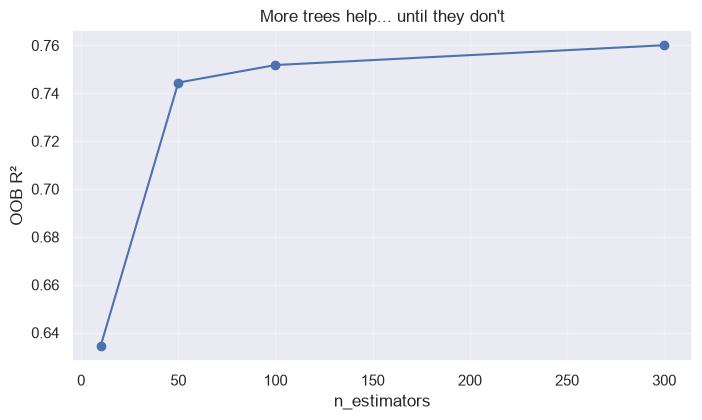

In [4]:
sizes = [10, 50, 100, 300]           # candidate committee sizes
oob_scores = []
for m in sizes:                      # fresh forest per size (oob needs its own fit)
    rfm = RandomForestRegressor(
        n_estimators=m, oob_score=True, random_state=42, n_jobs=-1,
    ).fit(X_train, y_train)
    oob_scores.append(rfm.oob_score_)                # OOB R² from this committee
    print(f"n_estimators={m:>3} → OOB R²={rfm.oob_score_:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(sizes, oob_scores, "o-")
ax.set(xlabel="n_estimators", ylabel="OOB R²",
       title="More trees help... until they don't")
ax.grid(alpha=0.3)
plt.show()

### 4. Permutation importance - the honest leaderboard

Impurity importances inflate correlated/high-cardinality features. Permutation
importance asks a harder question: *if I shuffle this feature, how much does
TEST performance drop?* Zero or negative drop ⇒ the model isn't really using it.

⚠️ Expect MedInc to dominate, with location (lat/long) next - geography IS
price in California.

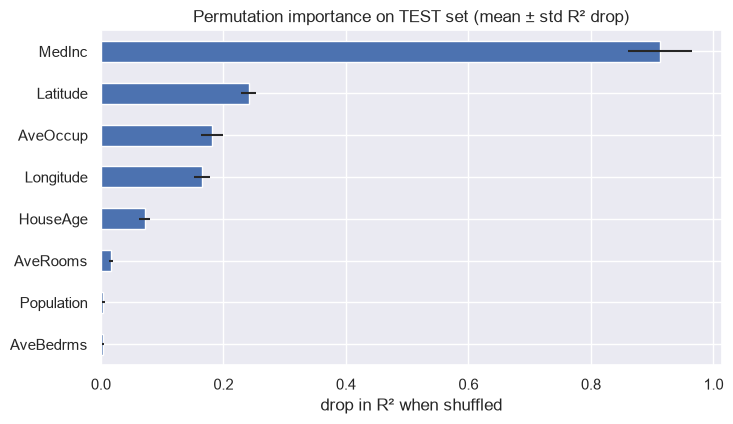

MedInc        0.9130
Latitude      0.2410
AveOccup      0.1814
Longitude     0.1649
HouseAge      0.0713
AveRooms      0.0170
Population    0.0042
AveBedrms     0.0039
dtype: float64


In [5]:
pi = permutation_importance(
    rf_base, X_test, y_test,
    n_repeats=10,                # shuffle each feature 10× for a stable estimate
    random_state=42,             # reproducible shuffles
    n_jobs=-1,                   # parallel repeats
)
pi_series = (
    pd.Series(pi.importances_mean, index=features)   # mean R² drop per feature
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
pi_series.plot.barh(xerr=pi.importances_std[np.argsort(pi.importances_mean)], ax=ax)
# ^ bars with error whiskers: tiny/negative bars = features the forest ignores
ax.set_title("Permutation importance on TEST set (mean ± std R² drop)")
ax.set_xlabel("drop in R² when shuffled")
plt.tight_layout(); plt.show()

print(pi_series.sort_values(ascending=False).round(4))   # tidy leaderboard print

### 5. Certification plot: actual vs predicted

The final sanity check every regression model deserves. Points hugging the
dashed y=x line = calibrated predictions; systematic bows or clipping reveal
bias. 💡 Note the horizontal smear near actual=5.0 - the dataset's \$500k cap.

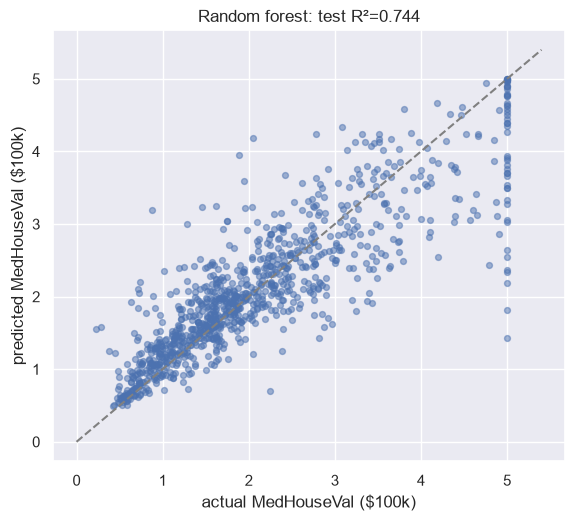

residuals: mean=-0.013  std=0.588  |worst|=3.572


In [6]:
pred_test = rf_base.predict(X_test)

fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax.scatter(y_test, pred_test, s=18, alpha=0.5)
lims = [0, 5.4]                      # target range including the cap
ax.plot(lims, lims, ls="--", c="gray")               # perfection reference y=x
ax.set(xlabel="actual MedHouseVal ($100k)",
       ylabel="predicted MedHouseVal ($100k)",
       title=f"Random forest: test R²={r2_score(y_test, pred_test):.3f}")
plt.show()

resid = y_test - pred_test
print(f"residuals: mean={resid.mean():+.3f}  std={resid.std():.3f}  "
      f"|worst|={np.abs(resid).max():.3f}")

### Summary & key takeaways

- `oob_score=True` turns the bootstrap leftovers into **free cross-validation**;
  OOB ≈ test R² here, so you could tune without ever opening the test set.
- The **OOB curve** rises fast then flattens: 100→300 trees bought little -
  choose compute accordingly (more trees never hurt accuracy, only speed).
- **Permutation importance** ranks MedInc clearly first, then latitude/
  longitude; features near zero are dead weight worth dropping.
- Train/OOB/test scores now agree - the train-test gap pathology of single
  unpruned trees is gone, which is the whole point of bagging.

💡 Next: projects - penguins 🟢, mpg 🟡, insurance 🟠, and an advanced OOB +
error-hotspot audit 🔴 (including why forests refuse to extrapolate).